In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering, HDBSCAN
from sklearn.metrics import accuracy_score, silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.feature_selection import VarianceThreshold
from scipy.optimize import linear_sum_assignment
from scipy.stats import skew, kurtosis
from sklearn.model_selection import GridSearchCV
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

# Загрузка и обзор данных

Загрузим датасет. Сразу же удалим неинформативные столбцы с метаданными, согласно описанию датасета.

In [2]:
dataset = pd.read_csv('Run200_Wave_0_1.txt', sep=' ', header=None, skipinitialspace=True)
dataset = dataset.drop([0, 1, 2, 3, 504], axis=1)
dataset.columns = list(range(500))
dataset

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251,252,253,254,255,256,257,258,259,260,261,262,263,264,265,266,267,268,269,270,271,272,273,274,275,276,277,278,279,280,281,282,283,284,285,286,287,288,289,290,291,292,293,294,295,296,297,298,299,300,301,302,303,304,305,306,307,308,309,310,311,312,313,314,315,316,317,318,319,320,321,322,323,324,325,326,327,328,329,330,331,332,333,334,335,336,337,338,339,340,341,342,343,344,345,346,347,348,349,350,351,352,353,354,355,356,357,358,359,360,361,362,363,364,365,366,367,368,369,370,371,372,373,374,375,376,377,378,379,380,381,382,383,384,385,386,387,388,389,390,391,392,393,394,395,396,397,398,399,400,401,402,403,404,405,406,407,408,409,410,411,412,413,414,415,416,417,418,419,420,421,422,423,424,425,426,427,428,429,430,431,432,433,434,435,436,437,438,439,440,441,442,443,444,445,446,447,448,449,450,451,452,453,454,455,456,457,458,459,460,461,462,463,464,465,466,467,468,469,470,471,472,473,474,475,476,477,478,479,480,481,482,483,484,485,486,487,488,489,490,491,492,493,494,495,496,497,498,499
0,14820,14823,14824,14822,14818,14820,14824,14822,14820,14820,14820,14822,14824,14820,14828,14819,14822,14822,14820,14822,14820,14819,14820,14821,14815,14830,14824,14825,14820,14820,14824,14822,14817,14825,14820,14814,14822,14823,14824,14820,14820,14823,14822,14817,14824,14826,14823,14822,14818,14822,14820,14817,14820,14821,14822,14820,14818,14820,14820,14825,14818,14819,14824,14822,14818,14820,14827,14826,14824,14819,14820,14822,14820,14820,14822,14825,14822,14821,14817,14822,14819,14821,14823,14821,14817,14820,14827,14820,14820,14823,14820,14815,14820,14822,14820,14824,14817,14818,14819,14822,14819,14818,14827,14820,14818,14820,14819,14818,14820,14824,14822,14820,14817,14822,14820,14817,14824,14822,14823,14824,14820,14825,14818,14823,14817,14820,14824,14824,14815,14820,14820,14822,14817,14822,14820,14820,14820,14822,14820,14819,14818,14823,14818,14818,14820,14814,14763,14563,14378,14291,14378,14460,14532,14607,14630,14681,14732,14741,14748,14756,14772,14779,14790,14792,14799,14801,14799,14797,14792,14803,14798,14794,14794,14814,14808,14811,14810,14807,14815,14810,14807,14801,14804,14804,14801,14801,14810,14806,14791,14813,14799,14802,14804,14811,14812,14803,14803,14812,14816,14819,14812,14809,14817,14817,14815,14817,14820,14817,14812,14816,14819,14816,14815,14822,14806,14817,14809,14813,14810,14813,14812,14819,14812,14815,14812,14823,14810,14810,14819,14819,14822,14813,14816,14820,14816,14817,14820,14819,14817,14821,14820,14826,14819,14820,14820,14826,14819,14821,14812,14820,14817,14813,14812,14815,14815,14814,14817,14817,14817,14815,14814,14820,14815,14813,14810,14820,14822,14821,14818,14818,14819,14820,14812,14818,14820,14816,14818,14819,14817,14819,14820,14816,14817,14816,14819,14819,14818,14818,14817,14820,14818,14824,14823,14813,14817,14818,14815,14825,14819,14827,14818,14815,14820,14823,14815,14822,14827,14822,14818,14818,14818,14822,14812,14830,14819,14817,14823,14828,14824,14810,14817,14827,14823,14814,14820,14821,14820,14816,14818,14828,14818,14822,14819,14823,14817,14816,14824,14822,14823,14818,14822,14825,14820,14823,14818,14822,14820,14820,14818,14823,14819,1

Text(0, 0.5, 'bit ADC')

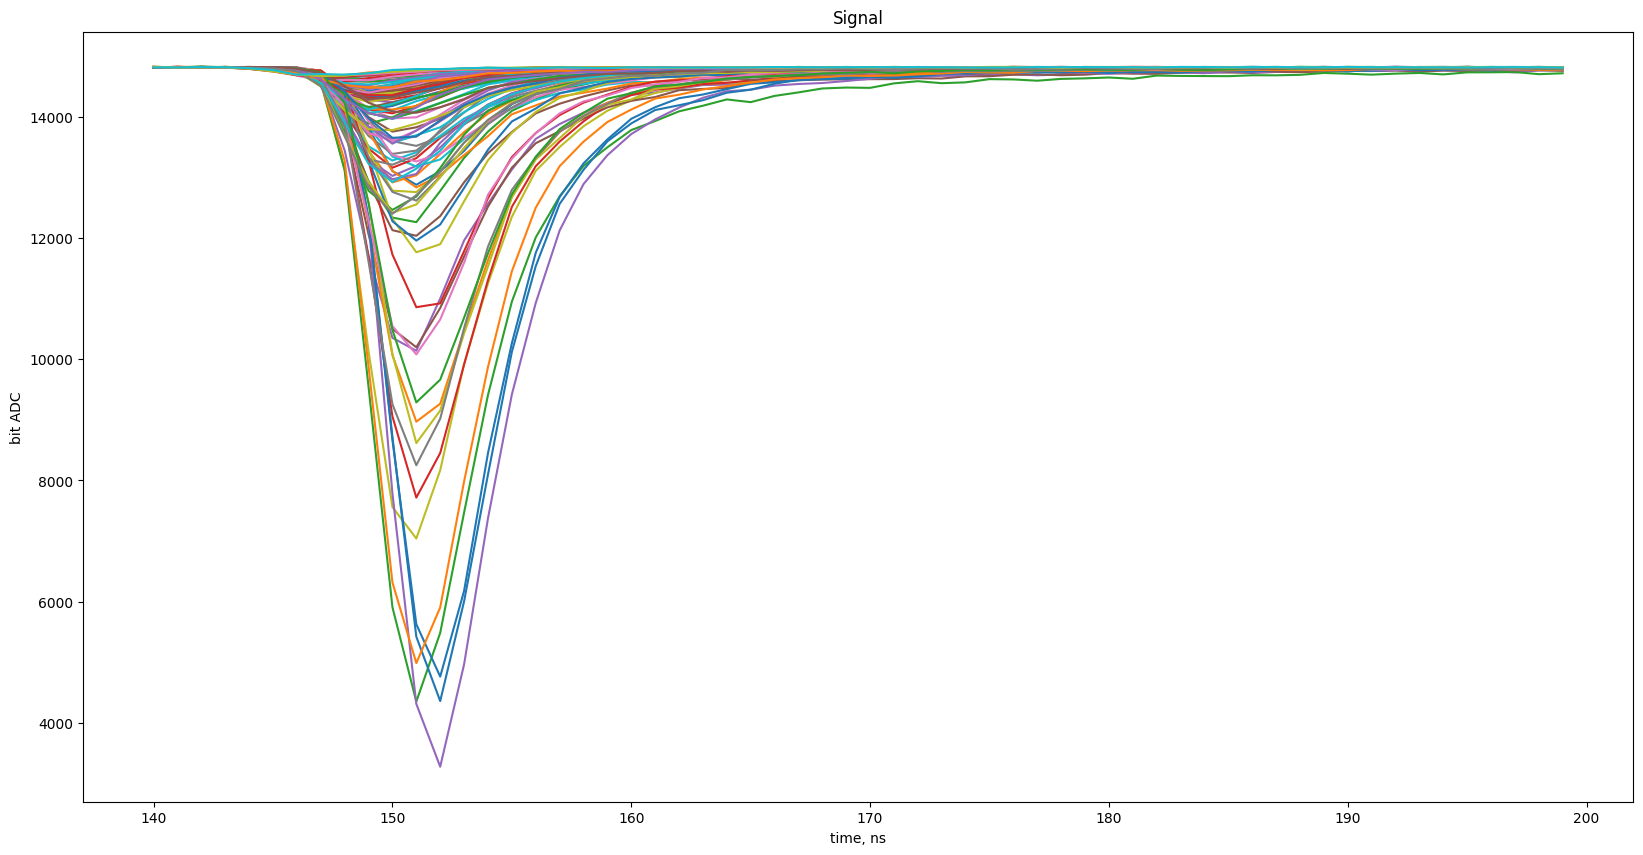

In [3]:
N=range(0,100)
ax = dataset.T[N][140:200].plot(title='Signal' ,legend=None,figsize=(20,10))
ax.set_xlabel("time, ns")
ax.set_ylabel("bit ADC")

Text(0, 0.5, 'bit ADC')

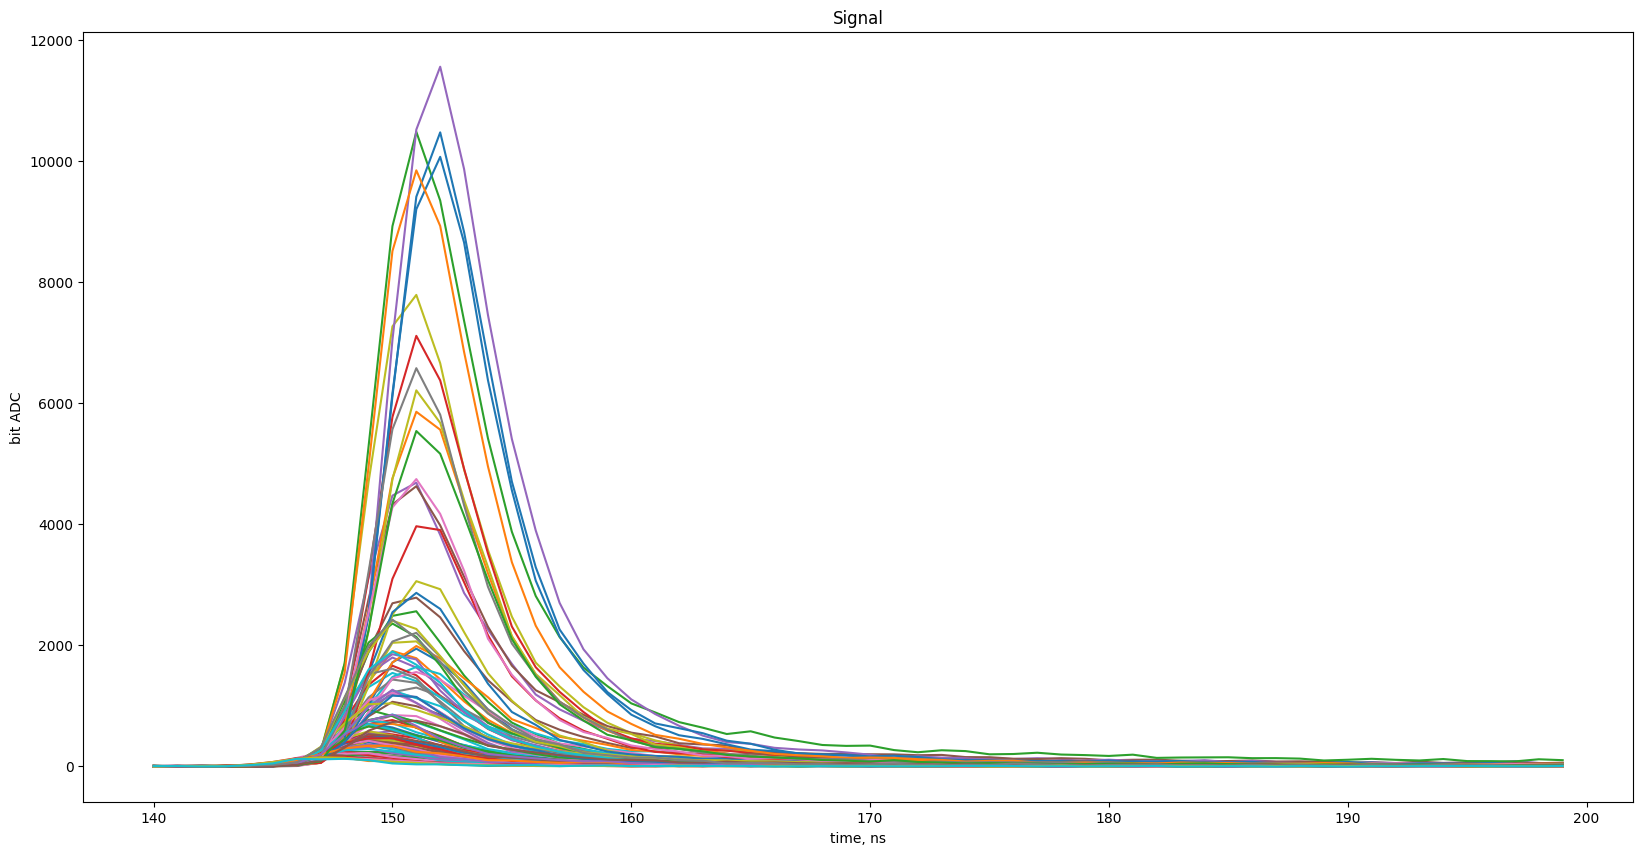

In [4]:
ax = (2**14-dataset.T[N]-1560)[140:200].plot(title='Signal' ,legend=None,figsize=(20,10))
ax.set_xlabel("time, ns")
ax.set_ylabel("bit ADC")

In [5]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23479 entries, 0 to 23478
Columns: 500 entries, 0 to 499
dtypes: int64(500)
memory usage: 89.6 MB


Датасет из 23479 строк с 500 признаками. Каждый признак является целочисленным значением - показателем детектора.

In [6]:
print("Строк с пропусками: ", len(dataset[dataset.isnull().any(axis=1)]))

Строк с пропусками:  0


In [7]:
print("Дубликатов:", dataset.duplicated().sum())

Дубликатов: 0


Пропусков и дубликатов нет.

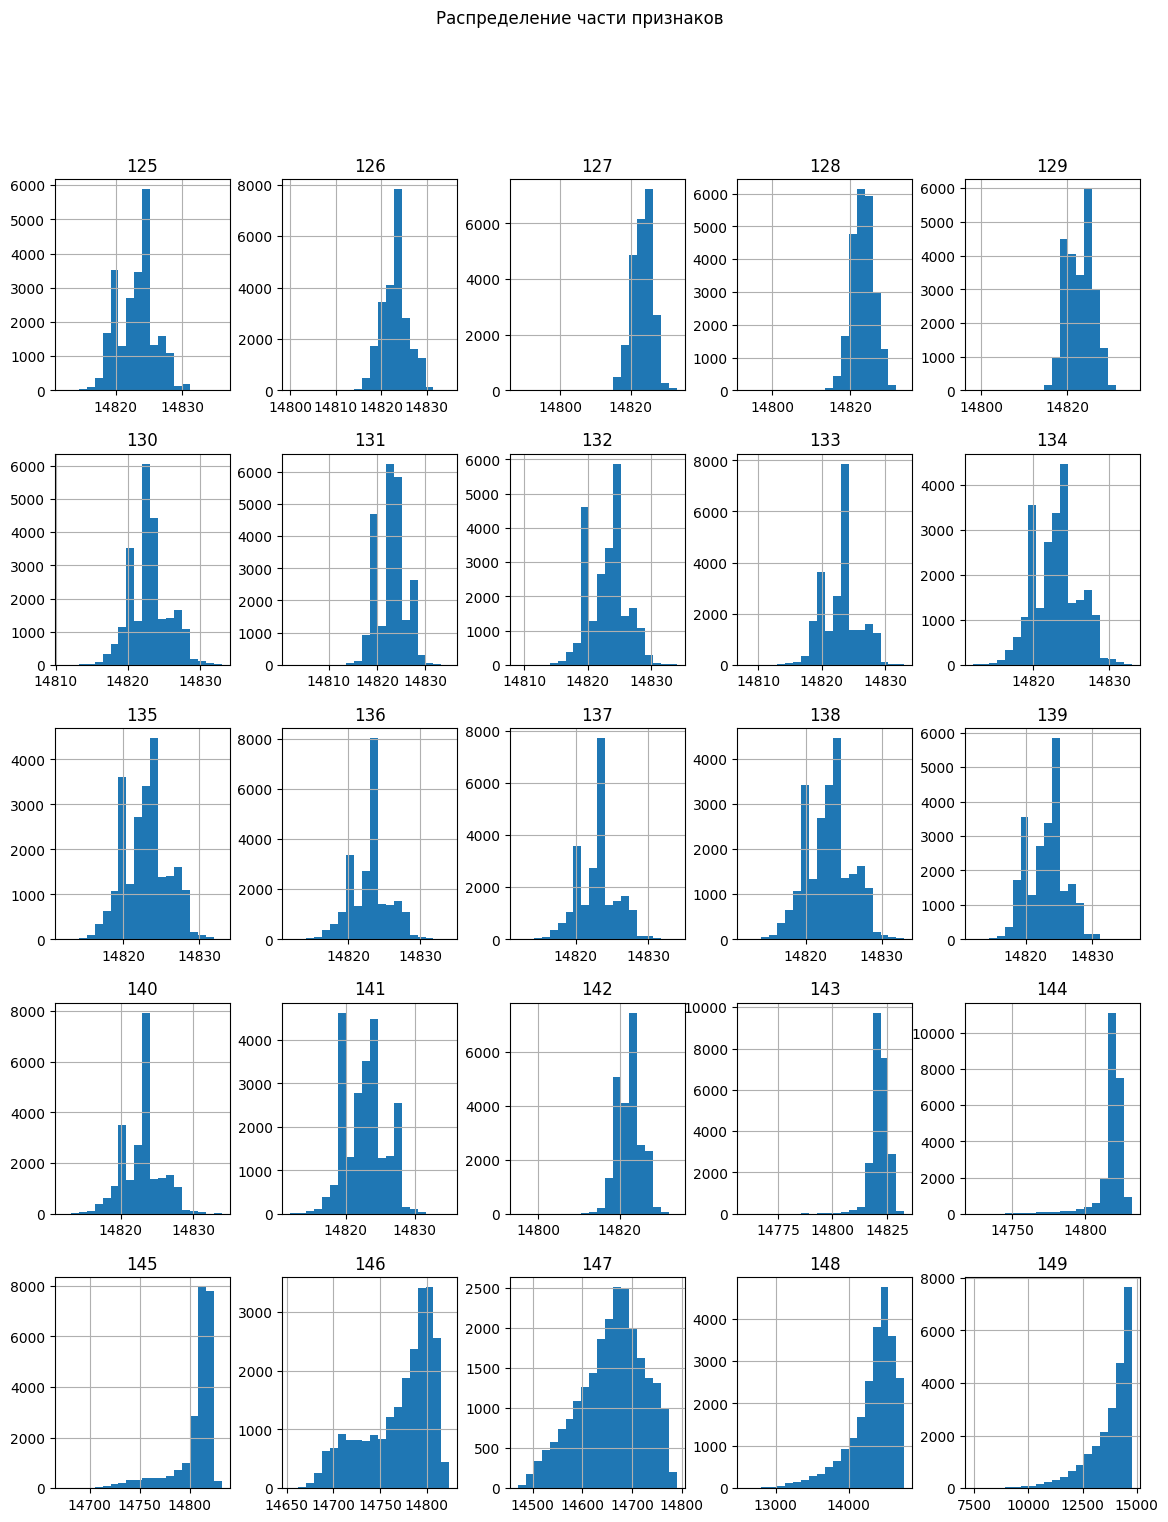

In [8]:
distribution_hist = dataset[dataset.columns[125:150]].hist(bins=20, figsize=(14, 17))
plt.suptitle("Распределение части признаков");

По гистограммам видно, что не все признаки имеют нормальное распределение. Также в данных есть выбросы.

In [9]:
outlier_counts = {}
for col in dataset.columns:
  Q1 = dataset[col].quantile(0.25)
  Q3 = dataset[col].quantile(0.75)
  IQR = Q3 - Q1
  lower = Q1 - 1.5 * IQR
  upper = Q3 + 1.5 * IQR
  outlier_counts[col] = [((dataset[col] < lower) | (dataset[col] > upper)).sum()]
outlier_counts = pd.DataFrame(outlier_counts)
print(f"Максимум выбросов на признак: {int(outlier_counts.max(axis=1).iloc[0])} ({(int(outlier_counts.max(axis=1).iloc[0]) / len(dataset)) * 100:.2f}%)")

Максимум выбросов на признак: 2768 (11.79%)


Выбросов не так много, но с ними стоит поработать.

# Предобработка данных

In [10]:
X = dataset.copy()

Удалим выбросы в данных, заменив их на граничные значения в соответствии с IQR.

In [11]:
for col in dataset.columns:
  Q1 = X[col].quantile(0.25)
  Q3 = X[col].quantile(0.75)
  IQR = Q3 - Q1
  lower = Q1 - 1.5 * IQR
  upper = Q3 + 1.5 * IQR
  X[col] = X[col].clip(lower, upper)

Проверим наличие константных признаков.

In [12]:
selector = VarianceThreshold()
X_varthres = selector.fit_transform(X)
print(f"Константных признаков: {X.shape[1] - X_varthres.shape[1]}")

Константных признаков: 0


Стандартизуем значения для дальнейшей работы.

In [13]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### Снижение размерности

Воспользуемся PCA, подберем число компонент так, чтобы метрики разных моделей были наилучшими. Проверяем KMeans, HDBSCAN и иерархическую кластеризацию.

In [14]:
n_range = [10, 20, 30, 50, 75, 100, 200, 300]

kmeans2_silhouette = []
kmeans2_calinski_harabasz = []
kmeans2_davies_bouldin = []

kmeans3_silhouette = []
kmeans3_calinski_harabasz = []
kmeans3_davies_bouldin = []

hdbscan_silhouette = []
hdbscan_calinski_harabasz = []
hdbscan_davies_bouldin = []

agg2_silhouette = []
agg2_calinski_harabasz = []
agg2_davies_bouldin = []

agg3_silhouette = []
agg3_calinski_harabasz = []
agg3_davies_bouldin = []

for n_components in n_range:
  print(f"N = {n_components}")
  pca = PCA(n_components=n_components, random_state=42)
  X_pca = pca.fit_transform(X_scaled)

  #KMeans (2 clusters)
  kmeans2 = KMeans(n_clusters=2, random_state=42, n_init="auto")
  kmeans2_labels = kmeans2.fit_predict(X_pca)
  kmeans2_silhouette.append(silhouette_score(X_pca, kmeans2_labels))
  kmeans2_calinski_harabasz.append(calinski_harabasz_score(X_pca, kmeans2_labels))
  kmeans2_davies_bouldin.append(davies_bouldin_score(X_pca, kmeans2_labels))

  #KMeans (3 clusters)
  kmeans3 = KMeans(n_clusters=3, random_state=42, n_init="auto")
  kmeans3_labels = kmeans3.fit_predict(X_pca)
  kmeans3_silhouette.append(silhouette_score(X_pca, kmeans3_labels))
  kmeans3_calinski_harabasz.append(calinski_harabasz_score(X_pca, kmeans3_labels))
  kmeans3_davies_bouldin.append(davies_bouldin_score(X_pca, kmeans3_labels))

  #HDBSCAN
  hdbscan = HDBSCAN(copy=True)
  hdbscan_labels = hdbscan.fit_predict(X_pca)
  hdbscan_silhouette.append(silhouette_score(X_pca, hdbscan_labels))
  hdbscan_calinski_harabasz.append(calinski_harabasz_score(X_pca, hdbscan_labels))
  hdbscan_davies_bouldin.append(davies_bouldin_score(X_pca, hdbscan_labels))

  #Agglomerative (2 clusters)
  agg2 = AgglomerativeClustering(n_clusters=2)
  agg2_labels = agg2.fit_predict(X_pca)
  agg2_silhouette.append(silhouette_score(X_pca, agg2_labels))
  agg2_calinski_harabasz.append(calinski_harabasz_score(X_pca, agg2_labels))
  agg2_davies_bouldin.append(davies_bouldin_score(X_pca, agg2_labels))

  #Agglomerative (3 clusters)
  agg3 = AgglomerativeClustering(n_clusters=3)
  agg3_labels = agg3.fit_predict(X_pca)
  agg3_silhouette.append(silhouette_score(X_pca, agg3_labels))
  agg3_calinski_harabasz.append(calinski_harabasz_score(X_pca, agg3_labels))
  agg3_davies_bouldin.append(davies_bouldin_score(X_pca, agg3_labels))

N = 10
N = 20
N = 30
N = 50
N = 75
N = 100
N = 200
N = 300


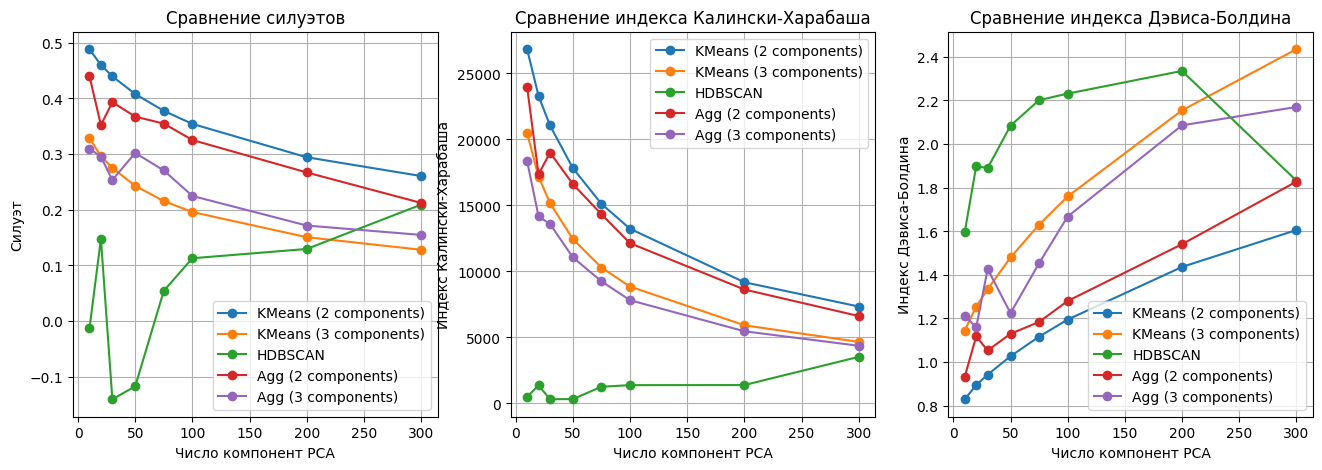

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].plot(n_range, kmeans2_silhouette, marker='o', label="KMeans (2 components)")
axes[0].plot(n_range, kmeans3_silhouette, marker='o', label="KMeans (3 components)")
axes[0].plot(n_range, hdbscan_silhouette, marker='o', label="HDBSCAN")
axes[0].plot(n_range, agg2_silhouette, marker='o', label="Agg (2 components)")
axes[0].plot(n_range, agg3_silhouette, marker='o', label="Agg (3 components)")
axes[0].set_title('Сравнение силуэтов')
axes[0].set_xlabel('Число компонент PCA')
axes[0].set_ylabel('Силуэт')
axes[0].grid(True)
axes[0].legend()

axes[1].plot(n_range, kmeans2_calinski_harabasz, marker='o', label="KMeans (2 components)")
axes[1].plot(n_range, kmeans3_calinski_harabasz, marker='o', label="KMeans (3 components)")
axes[1].plot(n_range, hdbscan_calinski_harabasz, marker='o', label="HDBSCAN")
axes[1].plot(n_range, agg2_calinski_harabasz, marker='o', label="Agg (2 components)")
axes[1].plot(n_range, agg3_calinski_harabasz, marker='o', label="Agg (3 components)")
axes[1].set_title('Сравнение индекса Калински-Харабаша')
axes[1].set_xlabel('Число компонент PCA')
axes[1].set_ylabel('Индекс Калински-Харабаша')
axes[1].grid(True)
axes[1].legend()

axes[2].plot(n_range, kmeans2_davies_bouldin, marker='o', label="KMeans (2 components)")
axes[2].plot(n_range, kmeans3_davies_bouldin, marker='o', label="KMeans (3 components)")
axes[2].plot(n_range, hdbscan_davies_bouldin, marker='o', label="HDBSCAN")
axes[2].plot(n_range, agg2_davies_bouldin, marker='o', label="Agg (2 components)")
axes[2].plot(n_range, agg3_davies_bouldin, marker='o', label="Agg (3 components)")
axes[2].set_title('Сравнение индекса Дэвиса-Болдина')
axes[2].set_xlabel('Число компонент PCA')
axes[2].set_ylabel('Индекс Дэвиса-Болдина')
axes[2].grid(True)
axes[2].legend()

На графиках видно, как меняется силуэт, индекс Калински-Харабаша и индекс Дэвиса-Болдина для каждой модели. Наилучшие метрики почти все модели показывают при **n_components** = 10. HDBSCAN, однако, строит наименее качественную кластеризацию.

Для следующих шагов возьмем **n_components** для PCA, равным 10.

# Тестирование разных моделей

Обучим KMeans, HDBSCAN и AgglomerativeClustering после PCA с 10 компонентами. Так как тренировочных данных нет, возьмем для каждого типа модели одну с наилучшими параметрами, выведем в отдельный файл и посмотрим на результат с Kaggle.

In [16]:
pca = PCA(n_components=10, random_state=42)
X_final = pca.fit_transform(X_scaled)

## KMeans

Проверим KMeans с разными параметрами и выберем лучшую.

In [17]:
def kmeans_sil_score(estimator, X):
    return silhouette_score(X, estimator.fit_predict(X))

param_grid = {
    "random_state": [42],
    "n_clusters": [2, 3],
}
kmeans_grid_search = GridSearchCV(KMeans(), param_grid=param_grid, scoring=kmeans_sil_score)
kmeans_grid_search.fit(X_final)

kmeans = kmeans_grid_search.best_estimator_
kmeans_labels = kmeans.predict(X_final)
sil_kmeans = silhouette_score(X_final, kmeans_labels)

print("KMeans с параметрами:")
print(kmeans.get_params)
print(f"Силуэт: {sil_kmeans}")

KMeans с параметрами:
<bound method BaseEstimator.get_params of KMeans(n_clusters=2, random_state=42)>
Силуэт: 0.4880979911824087


Наилучший силуэт дает KMeans с 2 кластерами.

### Вывод в файл и тестирование для KMeans.

In [18]:
kmeans_labels.shape

(23479,)

In [19]:
ans_kmeans = pd.DataFrame(data={"index": dataset.index, "cluster": kmeans_labels})
ans_kmeans["cluster"].value_counts()

cluster
0    17583
1     5896
Name: count, dtype: int64

При проверке на Kaggle лучший результат получается, если кластер 0 имеет меньше значений, чем кластер 1. Поэтому инвертируем метки.

In [20]:
for index, row in ans_kmeans.iterrows():
  if ans_kmeans.loc[index, "cluster"] == 0:
    ans_kmeans.loc[index, "cluster"] = 1
  elif ans_kmeans.loc[index, "cluster"] == 1:
    ans_kmeans.loc[index, "cluster"] = 0

In [21]:
ans_kmeans.head(3)

,index,cluster
0,0,1
1,1,1
2,2,1


In [22]:
ans_kmeans.to_csv("signal_types_clustering_kmeans.csv", index=False)

Тестирование на Kaggle дает accuracy = **0.56850**.

## HDBSCAN

Проверим несколько значений параметра **min_cluster_size** и определим наилучшую модель, а также ту, которая дает 2 кластера и кластер шума.

In [23]:
valid_hdbscan = {}
for min_cluster_size in [2, 3, 5, 7, 10]:
  hdbscan = HDBSCAN(copy=True, min_cluster_size=min_cluster_size)
  hdbscan_labels = hdbscan.fit_predict(X_final)
  sil_hdbscan = silhouette_score(X_final, hdbscan_labels)

  if len(np.unique(hdbscan_labels)) == 3:
    valid_hdbscan[min_cluster_size] = [sil_hdbscan, hdbscan, hdbscan_labels]

In [24]:
valid_hdbscan

{3: [np.float64(0.16381525536656488),
  HDBSCAN(copy=True, min_cluster_size=3),
  array([-1,  0,  0, ...,  0,  0,  0])],
 7: [np.float64(0.14188695527215006),
  HDBSCAN(copy=True, min_cluster_size=7),
  array([-1,  0,  0, ...,  0, -1, -1])],
 10: [np.float64(0.1491188811223612),
  HDBSCAN(copy=True, min_cluster_size=10),
  array([-1,  0,  0, ...,  0, -1, -1])]}

Наилучший силуэт с верным числом кластеров HDBSCAN дает при **min_cluster_size** = 3.

In [25]:
hdbscan = valid_hdbscan[3][1]
hdbscan_labels = valid_hdbscan[3][2]
sil_hdbscan = valid_hdbscan[3][0]

In [26]:
print("HDBSCAN с min_cluster_size = 3:")
print(f"Силуэт: {sil_hdbscan}")

HDBSCAN с min_cluster_size = 3:
Силуэт: 0.16381525536656488


Заменим кластеры с меткой -1 на 2, соответственно заданию.

In [27]:
hdbscan_labels[hdbscan_labels == -1] = 2

### Вывод в файл и тестирование для HDBSCAN.

In [28]:
hdbscan_labels.shape

(23479,)

In [29]:
ans_hdbscan = pd.DataFrame(data={"index": dataset.index, "cluster": hdbscan_labels})
ans_hdbscan["cluster"].value_counts()

cluster
0    22752
2      722
1        5
Name: count, dtype: int64

При проверке на Kaggle лучший результат получается, если кластер 0 имеет меньше значений, чем кластер 1. Поэтому инвертируем метки.

In [30]:
for index, row in ans_hdbscan.iterrows():
  if ans_hdbscan.loc[index, "cluster"] == 0:
    ans_hdbscan.loc[index, "cluster"] = 1
  elif ans_hdbscan.loc[index, "cluster"] == 1:
    ans_hdbscan.loc[index, "cluster"] = 0

In [31]:
ans_hdbscan.head(3)

,index,cluster
0,0,2
1,1,1
2,2,1


In [32]:
ans_hdbscan.to_csv("signal_types_clustering_hdbscan.csv", index=False)

Тестирование на Kaggle дает accuracy = **0.47885**.

### AgglomerativeClustering

Проверим иерархическую кластеризацию с разными параметрами и выберем лучшую.

In [33]:
agg2 = AgglomerativeClustering(n_clusters=2)
agg2_labels = agg2.fit_predict(X_final)
sil_agg2 = silhouette_score(X_final, agg2_labels)

In [34]:
print("Иерархическая кластеризация с параметрами:")
print(agg2.get_params)
print(f"Силуэт: {sil_agg2}")

Иерархическая кластеризация с параметрами:
<bound method BaseEstimator.get_params of AgglomerativeClustering()>
Силуэт: 0.43961714407781904


In [35]:
agg3 = AgglomerativeClustering(n_clusters=3)
agg3_labels = agg3.fit_predict(X_final)
sil_agg3 = silhouette_score(X_final, agg3_labels)

In [36]:
print("Иерархическая кластеризация с параметрами:")
print(agg3.get_params)
print(f"Силуэт: {sil_agg3}")

Иерархическая кластеризация с параметрами:
<bound method BaseEstimator.get_params of AgglomerativeClustering(n_clusters=3)>
Силуэт: 0.3096266533847064


Наилучший силуэт дает иерархическая кластеризация с 2 кластерами.

### Вывод в файл и тестирование для AgglomerativeClustering.

In [37]:
agg2_labels.shape

(23479,)

In [38]:
ans_agg2 = pd.DataFrame(data={"index": dataset.index, "cluster": agg2_labels})
ans_agg2["cluster"].value_counts()

cluster
1    15953
0     7526
Name: count, dtype: int64

In [39]:
ans_agg2.head(3)

,index,cluster
0,0,1
1,1,1
2,2,1


In [40]:
ans_agg2.to_csv("signal_types_clustering_agglomerative.csv", index=False)

Тестирование на Kaggle дает accuracy = **0.55406**.

# Вывод



Была произведена предобработка исходных данных, размерность датасета была снижена с помощью PCA с 10 компонентами. Были проверены 3 типа моделей: KMeans, HDBSCAN и иерархическая кластеризация.

**Accuracy** моделей:

KMeans - **0.56850**

HDBSCAN - **0.47885**

Agglomerative - **0.55406**

Наилучшей моделью оказалась **KMeans** параметром **n_clusters** = 2. Этот результат значит, что, скорее всего, модели не смогли выявить сложные кластеры и простого PCA тут недостаточно. В дальнейшем для этой задачи стоит провести комплексный Feature Engineering с анализом данных о сигналах, составляя новые признаки физических свойств сигналов, а также использовать нелинейные методы снижения размерности.

# Позиция в лидерборде

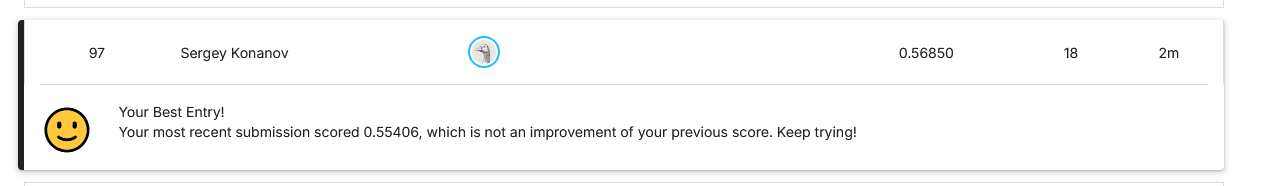